In [1]:
using IonSim
using QuantumOptics
using PyPlot

Compensating for Zeeman Offset: 56.11952854826818 Hz
Simulating bichromatic displacement (this may take a few seconds)...


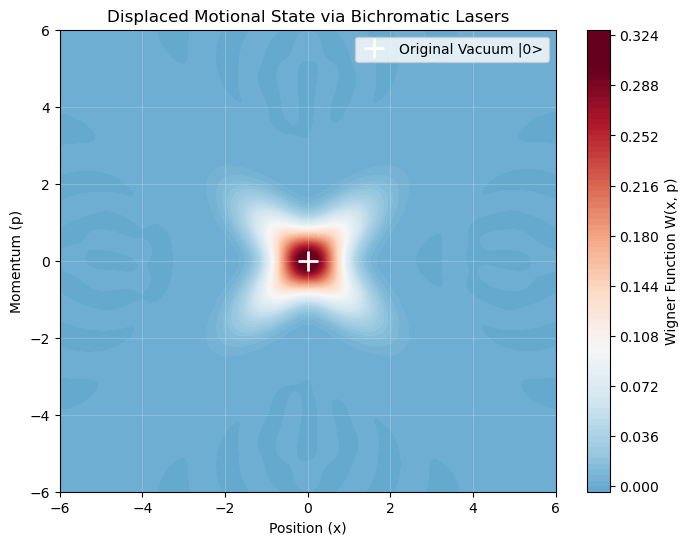

┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase C:\Users\jewoo\.julia\packages\SciMLBase\pzpcE\src\integrator_interface.jl:626


In [ ]:

# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
trap_freq = 1e6 # 1 MHz trap frequency
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])

# Define the trap chain using standard modes
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(;z=[1]))

# Increased N to 30 to give the wavepacket plenty of room to move without hitting the "walls"
mode_z = zmodes(chain)[1]
mode_z.N = 30 
mode_z.shape[1] =31

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
# Explicit NamedTuples for geometry to prevent Vector/NamedTuple math bugs
k_vec = (x=1/√2, y=0, z=1/√2)
ϵ_vec = (x=1/√2, y=0, z=-1/√2)

laser_intensity = 1e14 
transition_λ = 729e-9 
B_field = 1e-8

# Calculate the exact Zeeman offset
zeeman_offset = IonSim.zeemanshift(ion, "e", B_field) - IonSim.zeemanshift(ion, "g", B_field)
println("Compensating for Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
L_red = Laser(Δ = zeeman_offset - tra   p_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband
L_blue = Laser(Δ = zeeman_offset + trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

trap = Chamber(iontrap=chain, B=B_field, Bhat=(x=0,y=0,z=1), lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
mode = zmodes(trap)[1]

# FIX 1: EIGENSTATE ALIGNMENT
# The bichromatic force acts along the σ_y axis. 
# We MUST prepare the ion in the |+>_y state so it displaces cleanly as one wavepacket!
ψ_ion = normalize(ion["g"] + 1im * ion["e"])

# Initialize motional vacuum
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode

# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# FIX 2: APPLY THE RWA
# rwa_cutoff=3e5 (300 kHz) mathematically deletes the 1 MHz carrier oscillations,
# leaving ONLY the pure, resonant sideband displacement force!
h = hamiltonian(trap, timescale=1e-6, lamb_dicke_order=1, rwa_cutoff=Inf)

# Run for 100 microseconds to build up the displacement
tspan = 0:1.0:100.0 
println("Simulating bichromatic displacement (this may take a few seconds)...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# Trace out the ion to get the motional density matrix
rho_motional = ptrace(final_state, 1)

# Must match the N=30 dimension we set at the top!
b_fock = FockBasis(30)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Expanded the grid to 6.0 so we can see the full displaced wavepacket
x_vec = -6.0:0.1:6.0
p_vec = -6.0:0.1:6.0

# Calculate the Wigner quasiprobability distribution
W = wigner(rho_fock, x_vec, p_vec)

# Plotting
fig = figure(figsize=(8, 6))
contourf(x_vec, p_vec, W, 100, cmap="RdBu_r", vmin=-0.1, vmax=0.3)
colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

xlabel("Position (x)")
ylabel("Momentum (p)")
title("Displaced Motional State via Bichromatic Lasers")
legend()
grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter
display(fig)

In [3]:
using LinearAlgebra: norm, tr

println("\n" * "="^50)
println("🕵️‍♂️ SQRLAB RAW DIAGNOSTICS REPORT")
println("="^50)

# ---------------------------------------------------------
# DIAGNOSTIC 1: Exact Laser Detunings
# ---------------------------------------------------------
println("\n[DIAGNOSTIC 1] Laser Frequencies")
println("Red Laser Detuning (Δ)  : ", L_red.Δ, " Hz")
println("Blue Laser Detuning (Δ) : ", L_blue.Δ, " Hz")
println("Trap Frequency (ω_m)    : ", trap_freq, " Hz")
println("Difference (should match 2*ω_m): ", abs(L_blue.Δ - L_red.Δ), " Hz")

# ---------------------------------------------------------
# DIAGNOSTIC 2: Type Tracker for Rabi Frequency Math
# ---------------------------------------------------------
println("\n[DIAGNOSTIC 2] Coupling Math Breakdown")

println("-> Step A: Evaluating Matrix Element...")
c_matrix_elem = IonSim.matrixelement(ion, ("g", "e"), 1.0, L_red.k, L_red.ϵ, trap.Bhat)
println("   Value  = ", c_matrix_elem)
println("   Type   = ", typeof(c_matrix_elem))

println("\n-> Step B: Evaluating Laser Intensity (L_red.I)...")
println("   Value  = ", L_red.I)
println("   Type   = ", typeof(L_red.I))
println("   Notice: Is this a Float, or a time-dependent function wrapper?")

println("\n-> Step C: Evaluating Physics Constants...")
println("   IonSim.c  type = ", typeof(IonSim.c))
println("   IonSim.ε₀ type = ", typeof(IonSim.ϵ₀))

println("\n-> Step D: Step-by-Step Math execution...")
try
    println("   Attempting: 2 * L_red.I")
    val1 = 2 * L_red.I
    println("   [SUCCESS] Result = ", val1)
catch e
    println("   [FAILED]  Error: ", typeof(e))
end

try
    println("\n   Attempting: Calling L_red.I at t=0.0 (e.g., L_red.I(0.0))")
    val2 = 2 * L_red.I(0.0)
    println("   [SUCCESS] Result = ", val2)
    
    # If this succeeds, we can finish the math!
    E_field_test = sqrt(val2 / (IonSim.c * IonSim.ϵ₀))
    raw_rabi_test = abs(c_matrix_elem * E_field_test / IonSim.h)
    println("   [SUCCESS] Computed Rabi Frequency = ", raw_rabi_test / 1e3, " kHz")
catch e
    println("   [FAILED]  Error: ", typeof(e))
end

# ---------------------------------------------------------
# DIAGNOSTIC 3: Motional State (Phonon) Evolution
# ---------------------------------------------------------
b_fock_debug = FockBasis(mode_z.N)
a_op = QuantumOptics.destroy(b_fock_debug)
n_op = QuantumOptics.number(b_fock_debug)
x_op = (dagger(a_op) + a_op) / sqrt(2)
p_op = 1im * (dagger(a_op) - a_op) / sqrt(2)

phonon_tracking = Float64[]
x_tracking = Float64[]
p_tracking = Float64[]

for state in sol
    rho_m = ptrace(state, 1)
    rho_f = DenseOperator(b_fock_debug, rho_m.data)
    
    push!(phonon_tracking, real(expect(n_op, rho_f)))
    push!(x_tracking, real(expect(x_op, rho_f)))
    push!(p_tracking, real(expect(p_op, rho_f)))
end

println("\n[DIAGNOSTIC 3] Motional Growth")
println("Phonons at t = 0 μs   : ", phonon_tracking[1])
println("Phonons at t = 100 μs : ", phonon_tracking[end])
println("Max Phonons reached   : ", maximum(phonon_tracking))

println("\n[DIAGNOSTIC 6] Phase Space Translation")
println("Max Position <x> shifted: ", maximum(abs.(x_tracking)))
println("Max Momentum <p> shifted: ", maximum(abs.(p_tracking)))
# ---------------------------------------------------------
# DIAGNOSTIC 4: Internal Spin State Integrity
# ---------------------------------------------------------
P_e = ionprojector(trap, "e")
e_pops = real.(expect(P_e, sol))
max_deviation = maximum(abs.(e_pops .- 0.5))

println("\n[DIAGNOSTIC 4] Spin State Dynamics")
println("Initial |e> population : ", e_pops[1])
println("Final |e> population   : ", e_pops[end])
println("Max deviation from 0.5 : ", max_deviation)

# ---------------------------------------------------------
# DIAGNOSTIC 5: Motional State Purity
# ---------------------------------------------------------
purity_tracking = [real(tr(ptrace(state, 1)^2)) for state in sol]
println("\n[DIAGNOSTIC 5] Motional State Purity")
println("Initial Purity : ", purity_tracking[1])
println("Final Purity   : ", purity_tracking[end])
println("="^50 * "\n")

# ---------------------------------------------------------
# VISUAL DIAGNOSTICS PLOTS
# ---------------------------------------------------------
fig_debug, (ax1, ax2, ax3) = subplots(3, 1, figsize=(8, 10))

ax1.plot(tspan, phonon_tracking, color="blue", linewidth=2)
ax1.set_title("Diagnostic 3: Average Phonon Number ⟨n⟩ over time")
ax1.set_ylabel("⟨n⟩")
ax1.grid(true, linestyle="--")

ax2.plot(tspan, e_pops, color="purple", linewidth=2)
ax2.set_title("Diagnostic 4: Excited State Population P(e) (Should remain ~0.5)")
ax2.set_ylabel("P(e)")
ax2.set_ylim(0, 1)
ax2.grid(true, linestyle="--")

ax3.plot(tspan, purity_tracking, color="green", linewidth=2)
ax3.set_title("Diagnostic 5: Motional State Purity (1.0 = Pure, <1.0 = Entangled)")
ax3.set_xlabel("Time (μs)")
ax3.set_ylabel("Tr(ρ²)")
ax3.set_ylim(0, 1.1)
ax3.grid(true, linestyle="--")

tight_layout()
display(fig_debug)


🕵️‍♂️ SQRLAB RAW DIAGNOSTICS REPORT

[DIAGNOSTIC 1] Laser Frequencies
Red Laser Detuning (Δ)  : -999943.8804714517 Hz
Blue Laser Detuning (Δ) : 1.0000561195285483e6 Hz
Trap Frequency (ω_m)    : 1.0e6 Hz
Difference (should match 2*ω_m): 2.0e6 Hz

[DIAGNOSTIC 2] Coupling Math Breakdown
-> Step A: Evaluating Matrix Element...
   Value  = 123.1100040598802
   Type   = Float64

-> Step B: Evaluating Laser Intensity (L_red.I)...
   Value  = It
   Type   = IonSim.var"#It#25"{Float64}
   Notice: Is this a Float, or a time-dependent function wrapper?

-> Step C: Evaluating Physics Constants...
   IonSim.c  type = IonSim.PhysicalConstants.PhysicalConstant
   IonSim.ε₀ type = IonSim.PhysicalConstants.PhysicalConstant

-> Step D: Step-by-Step Math execution...
   Attempting: 2 * L_red.I
   [FAILED]  Error: MethodError

   Attempting: Calling L_red.I at t=0.0 (e.g., L_red.I(0.0))
   [SUCCESS] Result = 2.0e14
   [FAILED]  Error: UndefVarError

[DIAGNOSTIC 3] Motional Growth
Phonons at t = 0 μs   : 

PyCall.PyError: PyError ($(Expr(:escape, :(ccall(#= C:\Users\jewoo\.julia\packages\PyCall\1gn3u\src\pyfncall.jl:43 =# @pysym(:PyObject_Call), PyPtr, (PyPtr, PyPtr, PyPtr), o, pyargsptr, kw))))) <class 'ValueError'>
ValueError('x and y must have same first dimension, but have shapes (101,) and (3,)')
  File "C:\Users\jewoo\.julia\conda\3\x86_64\Lib\site-packages\matplotlib\axes\_axes.py", line 1777, in plot
    lines = [*self._get_lines(self, *args, data=data, **kwargs)]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jewoo\.julia\conda\3\x86_64\Lib\site-packages\matplotlib\axes\_base.py", line 297, in __call__
    yield from self._plot_args(
               ^^^^^^^^^^^^^^^^
  File "C:\Users\jewoo\.julia\conda\3\x86_64\Lib\site-packages\matplotlib\axes\_base.py", line 494, in _plot_args
    raise ValueError(f"x and y must have same first dimension, but "
